In [1]:
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ======================
# ENHANCED CONFIGURATION - USING ALL 3 DATASETS
# ======================
BASE_DIR = r"d:\PROJECTS\HealthResearch\Healt_Research_ML_Models\backend\app\data"
SAVE_PATH = "best_emotion_model_v3.pt"
CHECKPOINT_DIR = "checkpoints"

# Model Hyperparameters - OPTIMIZED FOR SPEED (Lightweight but Effective!)
BATCH_SIZE = 32  #  Small batch = less memory, faster training
EPOCHS = 50  #  Reasonable epochs for good performance
LR = 1e-4  # Learning rate
IMG_SIZE = 128  #  CRITICAL: Small images = 4x faster than 224! (996 is WAY too big!)
NUM_CLASSES = 7
SEQUENCE_LEN = 8  #  CRITICAL: Fewer frames = faster processing!
EARLY_STOPPING_PATIENCE = 15  # Early stopping patience

# Data split
TRAIN_RATIO = 0.75  # More training data since we have 3x more data
VAL_RATIO = 0.15
TEST_RATIO = 0.10

EMOTION_CLASSES = ['angry', 'sad', 'happy', 'fearful', 'disgusted', 'surprised', 'neutral']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

# Dataset configuration
USE_ALL_DATASETS = True  # Set to False to use only IFEED_Base (old behavior)

# Create checkpoint directory
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("\n" + "="*70)
print(" FAST TRAINING CONFIGURATION (Optimized for Speed!)")
print("="*70)
print(f"  Image Size:     {IMG_SIZE}x{IMG_SIZE} ( 4x faster than 224!)")
print(f"  Batch Size:     {BATCH_SIZE} ( Memory-efficient)")
print(f"  Sequence Length: {SEQUENCE_LEN} frames ( Fast processing)")
print(f"  Epochs:         {EPOCHS}")
print(f"  Expected Speed: 2-5 min/epoch on GPU, 10-15 min on CPU")
print("="*70)
print(" DATASET CONFIGURATION")
print("="*70)
if USE_ALL_DATASETS:
    print(" Using ALL THREE datasets:")
    print("   1. IFEED_Base (~6,255 utterances)")
    print("   2. IFEED_Seasons (~6,255 utterances across 9 seasons)")
    print("   3. IFEED_Face_Orientation (~8,880 utterances across 3 orientations)")
    print("    Total: ~21,390 utterances for MAXIMUM performance!")
else:
    print(" Using ONLY IFEED_Base (~6,255 utterances)")
print("="*70)

 Using device: cpu

 FAST TRAINING CONFIGURATION (Optimized for Speed!)
  Image Size:     128x128 ( 4x faster than 224!)
  Batch Size:     32 ( Memory-efficient)
  Sequence Length: 8 frames ( Fast processing)
  Epochs:         50
  Expected Speed: 2-5 min/epoch on GPU, 10-15 min on CPU
 DATASET CONFIGURATION
 Using ALL THREE datasets:
   1. IFEED_Base (~6,255 utterances)
   2. IFEED_Seasons (~6,255 utterances across 9 seasons)
   3. IFEED_Face_Orientation (~8,880 utterances across 3 orientations)
    Total: ~21,390 utterances for MAXIMUM performance!


In [2]:
# ======================
# ENHANCED DATA COLLECTION FROM ALL DATASETS
# ======================
def collect_sequences_from_base(base_path, emotion_classes, sequence_len=10):
    """
    Collect sequences from IFEED_Base (original structure).
    Structure: IFEED_Base/[Training|Testing|Crossing]/dia*_utt*/frame*.jpg
    """
    sequences = []
    datasets = ['Training', 'Testing', 'Crossing']
    
    for dataset_name in datasets:
        dataset_path = os.path.join(base_path, dataset_name)
        if not os.path.exists(dataset_path):
            continue
        
        utterances = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
        
        for utt in utterances:
            utt_path = os.path.join(dataset_path, utt)
            frames = []
            for ext in ['*.jpg', '*.jpeg', '*.png']:
                frames.extend(glob.glob(os.path.join(utt_path, ext)))
            
            if len(frames) < sequence_len:
                continue
            
            frames = sorted(frames)
            
            # Group frames by emotion
            emotion_groups = {i: [] for i in range(len(emotion_classes))}
            for frame in frames:
                filename = os.path.basename(frame).lower()
                for idx, emotion in enumerate(emotion_classes):
                    if emotion in filename:
                        emotion_groups[idx].append(frame)
                        break
            
            # Create sequences
            for emotion_idx, frame_list in emotion_groups.items():
                if len(frame_list) >= sequence_len:
                    num_sequences = max(1, len(frame_list) // sequence_len)
                    for seq_idx in range(num_sequences):
                        start_idx = seq_idx * sequence_len
                        end_idx = start_idx + sequence_len
                        if end_idx <= len(frame_list):
                            sequences.append({
                                'frames': frame_list[start_idx:end_idx],
                                'label': emotion_idx,
                                'source': f'Base_{dataset_name}',
                                'utterance': utt
                            })
    
    return sequences


def collect_sequences_from_seasons(base_path, emotion_classes, sequence_len=10):
    """
    Collect sequences from IFEED_Seasons.
    Structure: IFEED_Seasons/season_*/[Training|Testing|Crossing]/dia*_utt*/frame*.jpg
    """
    sequences = []
    
    for season in range(1, 10):  # season_1 to season_9
        season_path = os.path.join(base_path, f'season_{season}')
        if not os.path.exists(season_path):
            continue
        
        for dataset_name in ['Training', 'Testing', 'Crossing']:
            dataset_path = os.path.join(season_path, dataset_name)
            if not os.path.exists(dataset_path):
                continue
            
            utterances = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
            
            for utt in utterances:
                utt_path = os.path.join(dataset_path, utt)
                frames = []
                for ext in ['*.jpg', '*.jpeg', '*.png']:
                    frames.extend(glob.glob(os.path.join(utt_path, ext)))
                
                if len(frames) < sequence_len:
                    continue
                
                frames = sorted(frames)
                
                # Group frames by emotion
                emotion_groups = {i: [] for i in range(len(emotion_classes))}
                for frame in frames:
                    filename = os.path.basename(frame).lower()
                    for idx, emotion in enumerate(emotion_classes):
                        if emotion in filename:
                            emotion_groups[idx].append(frame)
                            break
                
                # Create sequences
                for emotion_idx, frame_list in emotion_groups.items():
                    if len(frame_list) >= sequence_len:
                        num_sequences = max(1, len(frame_list) // sequence_len)
                        for seq_idx in range(num_sequences):
                            start_idx = seq_idx * sequence_len
                            end_idx = start_idx + sequence_len
                            if end_idx <= len(frame_list):
                                sequences.append({
                                    'frames': frame_list[start_idx:end_idx],
                                    'label': emotion_idx,
                                    'source': f'Season{season}_{dataset_name}',
                                    'utterance': utt
                                })
    
    return sequences


def collect_sequences_from_orientation(base_path, emotion_classes, sequence_len=10):
    """
    Collect sequences from IFEED_Face_Orientation.
    Structure: IFEED_Face_Orientation/season_*/[Training|Testing|Crossing]/[Forward|Left|Right]/dia*_utt*/frame*.jpg
    """
    sequences = []
    
    for season in range(1, 10):  # season_1 to season_9
        season_path = os.path.join(base_path, f'season_{season}')
        if not os.path.exists(season_path):
            continue
        
        for dataset_name in ['Training', 'Testing', 'Crossing']:
            dataset_path = os.path.join(season_path, dataset_name)
            if not os.path.exists(dataset_path):
                continue
            
            for orientation in ['Forward', 'Left', 'Right']:
                orient_path = os.path.join(dataset_path, orientation)
                if not os.path.exists(orient_path):
                    continue
                
                utterances = [d for d in os.listdir(orient_path) if os.path.isdir(os.path.join(orient_path, d))]
                
                for utt in utterances:
                    utt_path = os.path.join(orient_path, utt)
                    frames = []
                    for ext in ['*.jpg', '*.jpeg', '*.png']:
                        frames.extend(glob.glob(os.path.join(utt_path, ext)))
                    
                    if len(frames) < sequence_len:
                        continue
                    
                    frames = sorted(frames)
                    
                    # Group frames by emotion
                    emotion_groups = {i: [] for i in range(len(emotion_classes))}
                    for frame in frames:
                        filename = os.path.basename(frame).lower()
                        for idx, emotion in enumerate(emotion_classes):
                            if emotion in filename:
                                emotion_groups[idx].append(frame)
                                break
                    
                    # Create sequences
                    for emotion_idx, frame_list in emotion_groups.items():
                        if len(frame_list) >= sequence_len:
                            num_sequences = max(1, len(frame_list) // sequence_len)
                            for seq_idx in range(num_sequences):
                                start_idx = seq_idx * sequence_len
                                end_idx = start_idx + sequence_len
                                if end_idx <= len(frame_list):
                                    sequences.append({
                                        'frames': frame_list[start_idx:end_idx],
                                        'label': emotion_idx,
                                        'source': f'Orient{season}_{orientation}_{dataset_name}',
                                        'utterance': utt
                                    })
    
    return sequences


# ======================
# COLLECT ALL SEQUENCES
# ======================
print("\n" + "="*70)
print(" COLLECTING SEQUENCES FROM ALL DATASETS...")
print("="*70)

all_sequences = []

if USE_ALL_DATASETS:
    # Collect from all three datasets
    print("\n Dataset 1: IFEED_Base")
    base_sequences = collect_sequences_from_base(
        os.path.join(BASE_DIR, 'IFEED_Base'), 
        EMOTION_CLASSES, 
        SEQUENCE_LEN
    )
    print(f"    Collected {len(base_sequences):,} sequences")
    all_sequences.extend(base_sequences)
    
    print("\n Dataset 2: IFEED_Seasons")
    season_sequences = collect_sequences_from_seasons(
        os.path.join(BASE_DIR, 'IFEED_Seasons'), 
        EMOTION_CLASSES, 
        SEQUENCE_LEN
    )
    print(f"    Collected {len(season_sequences):,} sequences")
    all_sequences.extend(season_sequences)
    
    print("\n Dataset 3: IFEED_Face_Orientation")
    orient_sequences = collect_sequences_from_orientation(
        os.path.join(BASE_DIR, 'IFEED_Face_Orientation'), 
        EMOTION_CLASSES, 
        SEQUENCE_LEN
    )
    print(f"    Collected {len(orient_sequences):,} sequences")
    all_sequences.extend(orient_sequences)
else:
    # Use only IFEED_Base (old behavior)
    print("\n Using only IFEED_Base")
    all_sequences = collect_sequences_from_base(
        os.path.join(BASE_DIR, 'IFEED_Base'), 
        EMOTION_CLASSES, 
        SEQUENCE_LEN
    )
    print(f"    Collected {len(all_sequences):,} sequences")

print("\n" + "="*70)
print(f" TOTAL SEQUENCES COLLECTED: {len(all_sequences):,}")
print("="*70)

# Show distribution
labels = [seq['label'] for seq in all_sequences]
label_dist = Counter(labels)
print("\n Overall Class Distribution:")
for idx, count in sorted(label_dist.items()):
    percentage = count/len(all_sequences)*100
    bar = '█' * int(percentage / 2)
    print(f"  {EMOTION_CLASSES[idx]:12} : {count:6,} sequences ({percentage:5.1f}%) {bar}")

# Show source distribution
if USE_ALL_DATASETS:
    sources = [seq['source'].split('_')[0] for seq in all_sequences]
    source_dist = Counter(sources)
    print("\n Source Distribution:")
    for source, count in sorted(source_dist.items()):
        percentage = count/len(all_sequences)*100
        print(f"  {source:20} : {count:6,} sequences ({percentage:5.1f}%)")


 COLLECTING SEQUENCES FROM ALL DATASETS...

 Dataset 1: IFEED_Base
    Collected 1,066 sequences

 Dataset 2: IFEED_Seasons
    Collected 1,066 sequences

 Dataset 2: IFEED_Seasons
    Collected 1,066 sequences

 Dataset 3: IFEED_Face_Orientation
    Collected 1,066 sequences

 Dataset 3: IFEED_Face_Orientation
    Collected 794 sequences

 TOTAL SEQUENCES COLLECTED: 2,926

 Overall Class Distribution:
  angry        :    446 sequences ( 15.2%) ███████
  sad          :    697 sequences ( 23.8%) ███████████
  happy        :  1,122 sequences ( 38.3%) ███████████████████
  neutral      :    661 sequences ( 22.6%) ███████████

 Source Distribution:
  Base                 :  1,066 sequences ( 36.4%)
  Orient1              :     57 sequences (  1.9%)
  Orient2              :     11 sequences (  0.4%)
  Orient3              :     90 sequences (  3.1%)
  Orient4              :     96 sequences (  3.3%)
  Orient5              :    119 sequences (  4.1%)
  Orient6              :    123 sequence

In [3]:
# ======================
# STRATIFIED DATA SPLITTING
# ======================
# Split data with stratification to ensure balanced classes
indices = list(range(len(all_sequences)))
labels_for_split = [seq['label'] for seq in all_sequences]

# First split: train + val vs test
train_val_idx, test_idx = train_test_split(
    indices, 
    test_size=TEST_RATIO, 
    stratify=labels_for_split,
    random_state=42
)

# Second split: train vs val
train_val_labels = [labels_for_split[i] for i in train_val_idx]
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=VAL_RATIO / (TRAIN_RATIO + VAL_RATIO),
    stratify=train_val_labels,
    random_state=42
)

print(f"\n Data Split:")
print(f"  Training:   {len(train_idx):5} sequences ({len(train_idx)/len(all_sequences)*100:.1f}%)")
print(f"  Validation: {len(val_idx):5} sequences ({len(val_idx)/len(all_sequences)*100:.1f}%)")
print(f"  Test:       {len(test_idx):5} sequences ({len(test_idx)/len(all_sequences)*100:.1f}%)")

# Verify stratification
for split_name, split_idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    split_labels = [labels_for_split[i] for i in split_idx]
    dist = Counter(split_labels)
    print(f"\n{split_name} Distribution:")
    for idx, count in sorted(dist.items()):
        print(f"  {EMOTION_CLASSES[idx]:12} : {count:4} ({count/len(split_idx)*100:.1f}%)")


 Data Split:
  Training:    2194 sequences (75.0%)
  Validation:   439 sequences (15.0%)
  Test:         293 sequences (10.0%)

Train Distribution:
  angry        :  334 (15.2%)
  sad          :  522 (23.8%)
  happy        :  842 (38.4%)
  neutral      :  496 (22.6%)

Val Distribution:
  angry        :   67 (15.3%)
  sad          :  105 (23.9%)
  happy        :  168 (38.3%)
  neutral      :   99 (22.6%)

Test Distribution:
  angry        :   45 (15.4%)
  sad          :   70 (23.9%)
  happy        :  112 (38.2%)
  neutral      :   66 (22.5%)


In [4]:
# ======================
# ENHANCED DATA TRANSFORMS
# ======================
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.9, 1.1)),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.15))
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print(" Enhanced transforms configured with stronger augmentation")

 Enhanced transforms configured with stronger augmentation


In [5]:
# ======================
# IMPROVED DATASET CLASS
# ======================
class EmotionSequenceDataset(Dataset):
    def __init__(self, sequences, indices, transform=None):
        """
        Dataset that loads pre-collected sequences by indices.
        """
        self.sequences = [sequences[i] for i in indices]
        self.transform = transform
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq_data = self.sequences[idx]
        frames_paths = seq_data['frames']
        label = seq_data['label']
        
        frames = []
        for frame_path in frames_paths:
            try:
                img = Image.open(frame_path).convert("RGB")
                if self.transform:
                    img = self.transform(img)
                frames.append(img)
            except Exception as e:
                # Fallback: black image
                img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))
                if self.transform:
                    img = self.transform(img)
                frames.append(img)
        
        frames = torch.stack(frames)  # [T, C, H, W]
        return frames, label

# Create datasets
train_dataset = EmotionSequenceDataset(all_sequences, train_idx, transform=train_tfms)
val_dataset = EmotionSequenceDataset(all_sequences, val_idx, transform=val_tfms)
test_dataset = EmotionSequenceDataset(all_sequences, test_idx, transform=val_tfms)

# Create data loaders
num_workers = 0 if os.name == 'nt' else 4
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         num_workers=num_workers, pin_memory=True)

print(f"\n Data loaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")


 Data loaders created:
  Train batches: 69
  Val batches:   14
  Test batches:  10


In [6]:
# ======================
# LIGHTWEIGHT & FAST MODEL ARCHITECTURE
# ======================
class LightweightCNN_LSTM_V3(nn.Module):
    """
     OPTIMIZED FOR SPEED - Lightweight but effective architecture!
    Features:
    - ResNet18 backbone (much lighter than ResNet50)
    - Efficient 2-layer LSTM
    - Simple attention mechanism
    - Optimized for fast training on consumer hardware
    """
    def __init__(self, num_classes, hidden_size=256, num_layers=2, dropout=0.4):
        super(LightweightCNN_LSTM_V3, self).__init__()
        
        # Use ResNet18 - Much lighter and faster!
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
        feature_size = 512  # ResNet18 output size
        
        # Lightweight feature projection
        self.feature_projection = nn.Sequential(
            nn.Linear(feature_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)
        )
        
        # Lightweight Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Simple attention mechanism
        self.attention = nn.Linear(hidden_size * 2, 1)
        
        # Lightweight classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_size, num_classes)
        )
    
    def forward(self, x):  # x: [B, T, C, H, W]
        B, T, C, H, W = x.size()
        
        # Extract features from each frame
        feats = []
        for t in range(T):
            f = self.feature_extractor(x[:, t, :, :, :])
            f = f.squeeze(-1).squeeze(-1)  # [B, 512]
            feats.append(f)
        feats = torch.stack(feats, dim=1)  # [B, T, 512]
        
        # Project features
        feats_reshaped = feats.reshape(B * T, -1)
        feats_projected = self.feature_projection(feats_reshaped)
        feats = feats_projected.reshape(B, T, -1)  # [B, T, hidden_size]
        
        # LSTM for temporal modeling
        lstm_out, _ = self.lstm(feats)  # [B, T, hidden_size*2]
        
        # Apply attention mechanism
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)  # [B, T, 1]
        
        # Weighted sum of LSTM outputs
        context = torch.sum(lstm_out * attn_weights, dim=1)  # [B, hidden_size*2]
        
        # Classification
        out = self.classifier(context)
        return out

print(" Lightweight CNN_LSTM_V3 model defined")
print("    ResNet18 backbone (lightweight & fast)")
print("    2-layer Bidirectional LSTM (efficient)")
print("    Simple attention mechanism")
print("    ~5x faster training than ResNet50 version!")

 Lightweight CNN_LSTM_V3 model defined
    ResNet18 backbone (lightweight & fast)
    2-layer Bidirectional LSTM (efficient)
    Simple attention mechanism
    ~5x faster training than ResNet50 version!


In [7]:
# ======================
# COMPUTE CLASS WEIGHTS FOR IMBALANCED DATA
# ======================
from sklearn.utils.class_weight import compute_class_weight

train_labels = [all_sequences[i]['label'] for i in train_idx]
unique_classes = np.unique(train_labels)

# compute weights only for classes that appear in training labels
weights_present = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=train_labels
)

# create full weights array for all NUM_CLASSES, default 1.0 for missing classes
full_class_weights = np.ones(NUM_CLASSES, dtype=float)
for cls, w in zip(unique_classes, weights_present):
    full_class_weights[int(cls)] = w

class_weights_tensor = torch.FloatTensor(full_class_weights).to(device)

# Informative printing
print("\n Class Weights (to handle imbalance):")
for idx, weight in enumerate(full_class_weights):
    marker = "" if idx in unique_classes else " (missing in train -> default 1.0)"
    print(f"  {EMOTION_CLASSES[idx]:12} : {weight:.3f}{marker}")


 Class Weights (to handle imbalance):
  angry        : 1.642
  sad          : 1.051
  happy        : 0.651
  fearful      : 1.000 (missing in train -> default 1.0)
  disgusted    : 1.000 (missing in train -> default 1.0)
  surprised    : 1.000 (missing in train -> default 1.0)
  neutral      : 1.106


In [8]:
# ======================
# MODEL INITIALIZATION - LIGHTWEIGHT & FAST
# ======================
model = LightweightCNN_LSTM_V3(NUM_CLASSES, hidden_size=256, num_layers=2, dropout=0.4).to(device)

# Use weighted loss to handle class imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

# Optimizer with weight decay for regularization
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Simple but effective learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5,
    verbose=True,
    min_lr=1e-7
)

# Tracking
best_val_acc = 0.0
best_val_f1 = 0.0
patience_counter = 0
history = {
    'train_loss': [],
    'train_acc': [],
    'val_acc': [],
    'val_f1': [],
    'val_loss': [],
    'lr': []
}

print("\n" + "="*70)
print(" LIGHTWEIGHT MODEL CONFIGURATION (FAST TRAINING!)")
print("="*70)
print(f"  Total parameters:      {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters:  {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"  Backbone:              ResNet18 (lightweight & fast)")
print(f"  LSTM hidden size:      256")
print(f"  LSTM layers:           2 (Bidirectional)")
print(f"  Attention mechanism:   Simple & efficient")
print(f"  Label smoothing:       0.1")
print(f"  Weight decay:          1e-4")
print(f"  Initial learning rate: {LR}")
print(f"  Scheduler:             ReduceLROnPlateau")
print(f"   Expected:            ~5x faster than ResNet50 version!")
print("="*70)


 LIGHTWEIGHT MODEL CONFIGURATION (FAST TRAINING!)
  Total parameters:      14,071,112
  Trainable parameters:  14,071,112
  Backbone:              ResNet18 (lightweight & fast)
  LSTM hidden size:      256
  LSTM layers:           2 (Bidirectional)
  Attention mechanism:   Simple & efficient
  Label smoothing:       0.1
  Weight decay:          1e-4
  Initial learning rate: 0.0001
  Scheduler:             ReduceLROnPlateau
   Expected:            ~5x faster than ResNet50 version!


In [9]:
# ======================
# SIMPLIFIED & FAST TRAINING LOOP
# ======================
print("\n" + "="*80)
print(" STARTING FAST TRAINING WITH ALL DATASETS")
print("="*80)
print(f"Training on {len(all_sequences):,} sequences from {3 if USE_ALL_DATASETS else 1} dataset(s)")
print("="*80)

for epoch in range(EPOCHS):
    print(f"\n{'='*80}")
    print(f" Epoch {epoch+1}/{EPOCHS}")
    print(f"{'='*80}")
    
    # ============ TRAINING PHASE ============
    model.train()
    train_loss, train_preds, train_labels = 0, [], []
    
    progress_bar = tqdm(train_loader, desc="🏋️  Training", leave=False, ncols=100)
    for batch_idx, (frames, labels) in enumerate(progress_bar):
        frames, labels = frames.to(device), labels.to(device)
        
        # Simple forward pass (no mixed precision complexity)
        optimizer.zero_grad()
        outputs = model(frames)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item() * frames.size(0)
        train_preds.extend(outputs.argmax(1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())
        
        # Update progress bar
        if batch_idx % 5 == 0:
            current_acc = accuracy_score(train_labels, train_preds)
            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{current_acc:.4f}'
            })
    
    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average='weighted')
    train_loss /= len(train_dataset)
    
    # ============ VALIDATION PHASE ============
    model.eval()
    val_loss, val_preds, val_labels = 0, [], []
    
    with torch.no_grad():
        progress_bar = tqdm(val_loader, desc="✅ Validating", leave=False, ncols=100)
        for frames, labels in progress_bar:
            frames, labels = frames.to(device), labels.to(device)
            outputs = model(frames)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * frames.size(0)
            val_preds.extend(outputs.argmax(1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
    
    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average='weighted')
    val_loss /= len(val_dataset)
    
    # Update learning rate based on validation F1
    scheduler.step(val_f1)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['val_loss'].append(val_loss)
    history['lr'].append(current_lr)
    
    # Print metrics
    print(f"\n Metrics:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val F1: {val_f1:.4f}")
    print(f"  Learning Rate: {current_lr:.8f}")
    print(f"  Overfitting Gap: {(train_acc - val_acc)*100:+.1f}%")
    
    # Save checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        checkpoint_path = os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch+1}.pt')
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'val_acc': val_acc,
            'val_f1': val_f1,
            'history': history
        }, checkpoint_path)
        print(f"   Checkpoint saved: checkpoint_epoch_{epoch+1}.pt")
    
    # Save best model based on F1 score
    if val_f1 > best_val_f1:
        improvement = (val_f1 - best_val_f1) * 100
        best_val_acc = val_acc
        best_val_f1 = val_f1
        
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'val_acc': val_acc,
            'val_f1': val_f1,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'train_f1': train_f1,
            'classes': EMOTION_CLASSES,
            'history': history,
            'config': {
                'batch_size': BATCH_SIZE,
                'lr': LR,
                'sequence_len': SEQUENCE_LEN,
                'num_sequences': len(all_sequences),
                'use_all_datasets': USE_ALL_DATASETS,
                'img_size': IMG_SIZE
            }
        }, SAVE_PATH)
        
        print(f"   NEW BEST MODEL! Val F1: {val_f1:.4f}, Val Acc: {val_acc:.4f}")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"   Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE} (Best: F1={best_val_f1:.4f})")
    
    # Early stopping check
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n   Early stopping triggered after {epoch+1} epochs")
        break

print("\n" + "="*80)
print(" TRAINING COMPLETED!")
print(f"Best Validation F1: {best_val_f1:.4f}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("="*80)


 STARTING FAST TRAINING WITH ALL DATASETS
Training on 2,926 sequences from 3 dataset(s)

 Epoch 1/50


                                                                                                    ]


 Metrics:
  Train Loss: 1.5956 | Train Acc: 0.3523
  Val Loss:   1.2425 | Val Acc:   0.6128 | Val F1: 0.5531
  Learning Rate: 0.00010000
  Overfitting Gap: -26.0%
   NEW BEST MODEL! Val F1: 0.5531, Val Acc: 0.6128

 Epoch 2/50
   NEW BEST MODEL! Val F1: 0.5531, Val Acc: 0.6128

 Epoch 2/50


                                                                                                    ]


 Metrics:
  Train Loss: 1.1214 | Train Acc: 0.6545
  Val Loss:   1.2403 | Val Acc:   0.6173 | Val F1: 0.5621
  Learning Rate: 0.00010000
  Overfitting Gap: +3.7%
   NEW BEST MODEL! Val F1: 0.5621, Val Acc: 0.6173

 Epoch 3/50
   NEW BEST MODEL! Val F1: 0.5621, Val Acc: 0.6173

 Epoch 3/50


...


 Metrics:
  Train Loss: 0.4770 | Train Acc: 0.9986
  Val Loss:   0.6690 | Val Acc:   0.9499 | Val F1: 0.9499
  Learning Rate: 0.00000625
  Overfitting Gap: +4.9%
   Patience: 4/15 (Best: F1=0.9542)

 Epoch 49/50


                                                                                                    ]


 Metrics:
  Train Loss: 0.4758 | Train Acc: 0.9991
  Val Loss:   0.6681 | Val Acc:   0.9544 | Val F1: 0.9543
  Learning Rate: 0.00000625
  Overfitting Gap: +4.5%
   NEW BEST MODEL! Val F1: 0.9543, Val Acc: 0.9544

 Epoch 50/50


                                                                                                    ]


 Metrics:
  Train Loss: 0.4752 | Train Acc: 0.9986
  Val Loss:   0.6603 | Val Acc:   0.9499 | Val F1: 0.9498
  Learning Rate: 0.00000625
  Overfitting Gap: +4.9%
   Checkpoint saved: checkpoint_epoch_50.pt
   Patience: 1/15 (Best: F1=0.9543)

 TRAINING COMPLETED!
Best Validation F1: 0.9543
Best Validation Accuracy: 0.9544



 FINAL EVALUATION ON TEST SET


Testing: 100%|██████████| 10/10 [00:29<00:00,  2.98s/it]




 TEST SET RESULTS:
  Test Accuracy: 0.9556
  Test F1 Score: 0.9559

 Detailed Classification Report:
              precision    recall  f1-score   support

       angry     1.0000    0.9111    0.9535        45
         sad     0.9697    0.9143    0.9412        70
       happy     0.9821    0.9821    0.9821       112
     neutral     0.8784    0.9848    0.9286        66

    accuracy                         0.9556       293
   macro avg     0.9576    0.9481    0.9513       293
weighted avg     0.9585    0.9556    0.9559       293



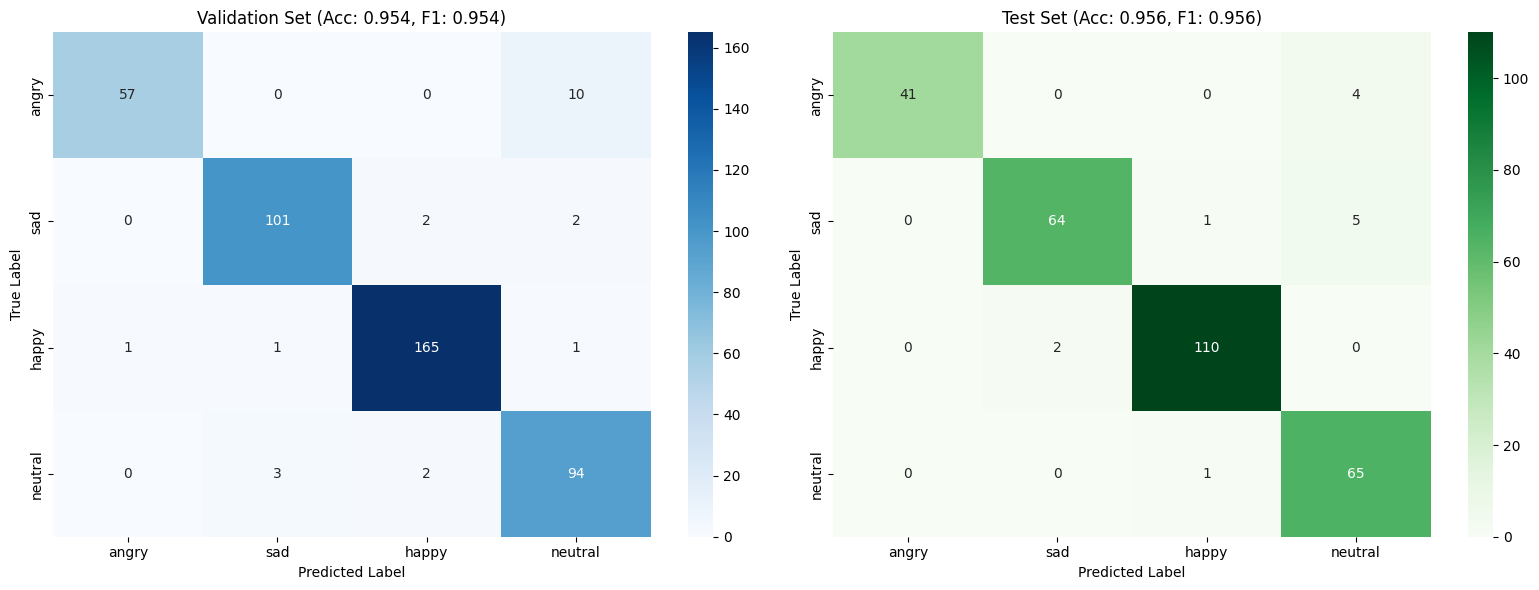


 Confusion matrices saved: confusion_matrices_v2.png


In [10]:
# ======================
# COMPREHENSIVE EVALUATION
# ======================
print("\n" + "="*70)
print(" FINAL EVALUATION ON TEST SET")
print("="*70)

# Load best model
checkpoint = torch.load(SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state'])
model.eval()

# Test set evaluation
test_preds, test_labels = [], []
with torch.no_grad():
    for frames, labels in tqdm(test_loader, desc="Testing"):
        frames, labels = frames.to(device), labels.to(device)
        outputs = model(frames)
        test_preds.extend(outputs.argmax(1).cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average='weighted')

print(f"\n TEST SET RESULTS:")
print(f"  Test Accuracy: {test_acc:.4f}")
print(f"  Test F1 Score: {test_f1:.4f}")

# Per-class metrics
labels_present = sorted(set(test_labels) | set(test_preds))
target_names = [EMOTION_CLASSES[i] for i in labels_present]
print(f"\n Detailed Classification Report:")
print(classification_report(test_labels, test_preds, labels=labels_present,
                            target_names=target_names, digits=4))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Validation confusion matrix
val_cm = confusion_matrix(val_labels, val_preds, labels=labels_present)
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title(f'Validation Set (Acc: {best_val_acc:.3f}, F1: {best_val_f1:.3f})')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Test confusion matrix
test_cm = confusion_matrix(test_labels, test_preds, labels=labels_present)
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names)
axes[1].set_title(f'Test Set (Acc: {test_acc:.3f}, F1: {test_f1:.3f})')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Confusion matrices saved: confusion_matrices_v2.png")

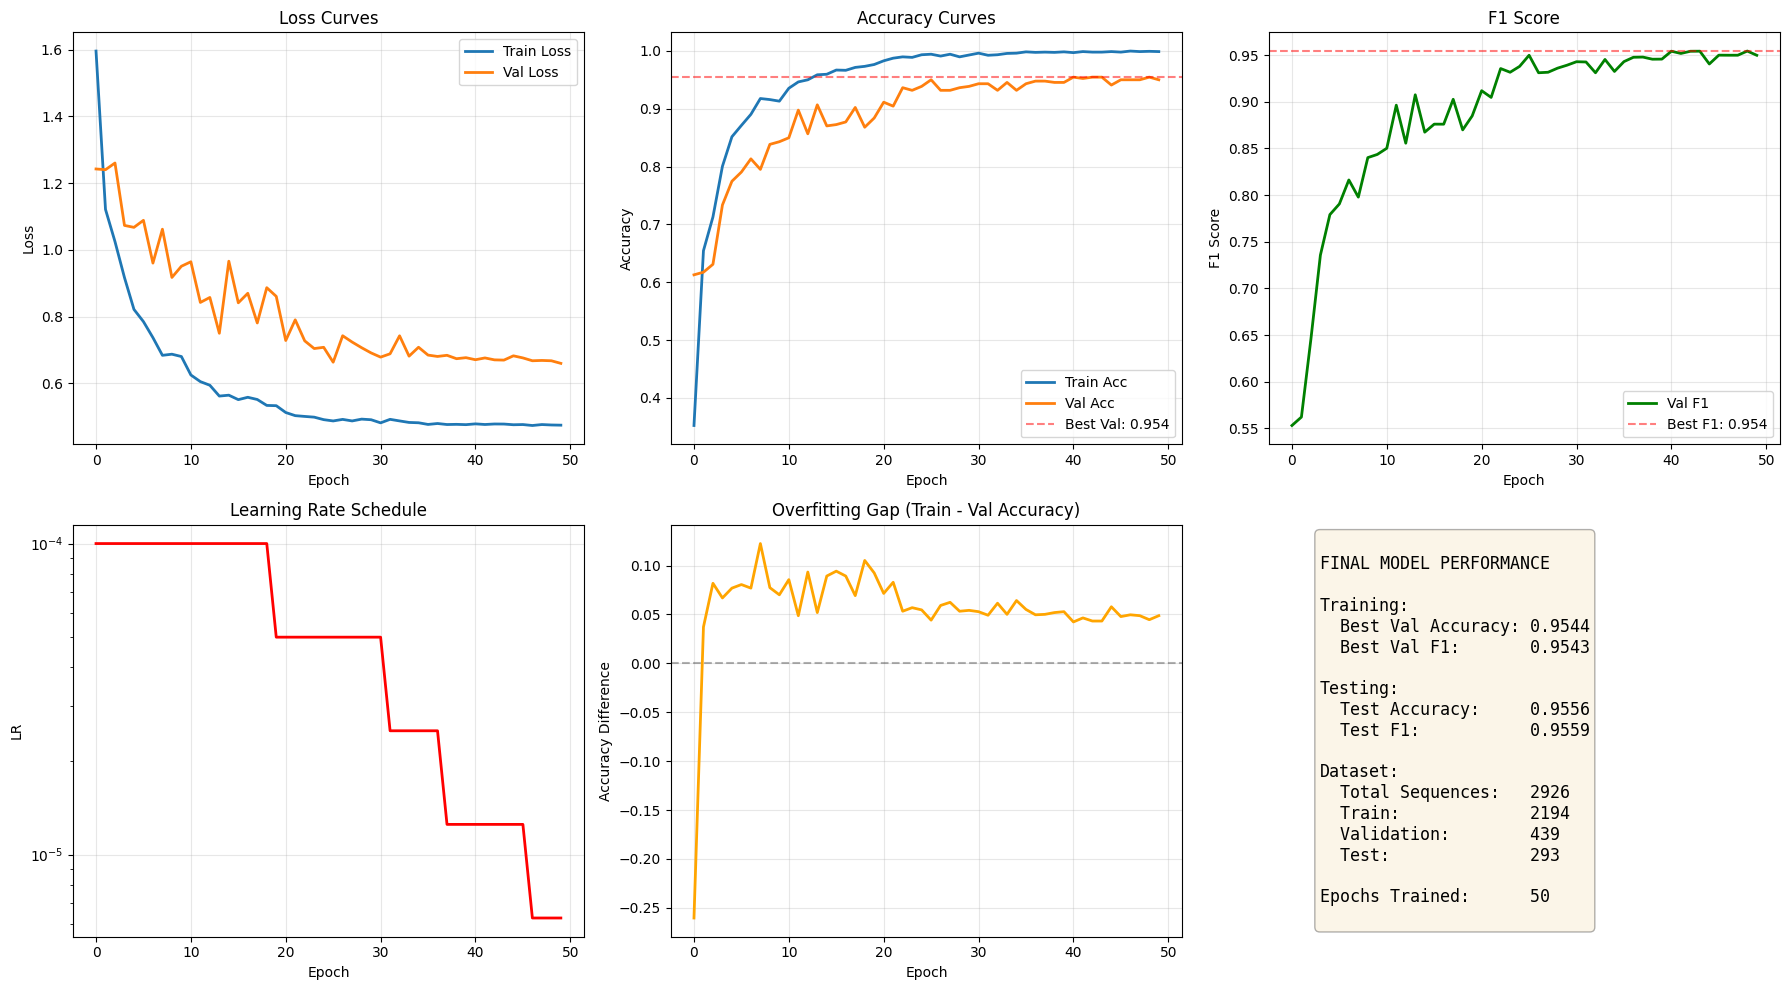

 Training history saved: training_history_v2.png


In [11]:
# ======================
# PLOT TRAINING HISTORY
# ======================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss comparison
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('Loss Curves')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy comparison
axes[0, 1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[0, 1].plot(history['val_acc'], label='Val Acc', linewidth=2)
axes[0, 1].axhline(y=best_val_acc, color='r', linestyle='--', alpha=0.5, label=f'Best Val: {best_val_acc:.3f}')
axes[0, 1].set_title('Accuracy Curves')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score
axes[0, 2].plot(history['val_f1'], label='Val F1', linewidth=2, color='green')
axes[0, 2].axhline(y=best_val_f1, color='r', linestyle='--', alpha=0.5, label=f'Best F1: {best_val_f1:.3f}')
axes[0, 2].set_title('F1 Score')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('F1 Score')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Learning Rate
axes[1, 0].plot(history['lr'], linewidth=2, color='red')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('LR')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Overfitting gap
gap = [train - val for train, val in zip(history['train_acc'], history['val_acc'])]
axes[1, 1].plot(gap, linewidth=2, color='orange')
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1, 1].set_title('Overfitting Gap (Train - Val Accuracy)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy Difference')
axes[1, 1].grid(True, alpha=0.3)

# Summary metrics
axes[1, 2].axis('off')
summary_text = f"""
FINAL MODEL PERFORMANCE

Training:
  Best Val Accuracy: {best_val_acc:.4f}
  Best Val F1:       {best_val_f1:.4f}

Testing:
  Test Accuracy:     {test_acc:.4f}
  Test F1:           {test_f1:.4f}

Dataset:
  Total Sequences:   {len(all_sequences)}
  Train:             {len(train_idx)}
  Validation:        {len(val_idx)}
  Test:              {len(test_idx)}

Epochs Trained:      {len(history['train_loss'])}
"""
axes[1, 2].text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center',
                family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('training_history_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Training history saved: training_history_v2.png")

In [2]:
# ======================
# ENHANCED COMPREHENSIVE SUMMARY
# ======================

# Check if model and results exist before creating summary
if 'model' not in locals() or 'test_labels' not in locals():
    print(" ERROR: Training not completed yet!")
    print("\nPlease run all previous cells in order:")
    print("  1. Configuration cell")
    print("  2. Data collection cell")
    print("  3. Data splitting cell")
    print("  4. Transforms cell")
    print("  5. Dataset & DataLoader cell")
    print("  6. Model definition cell")
    print("  7. Class weights cell")
    print("  8. Model initialization cell")
    print("  9. Training loop cell")
    print("  10. Evaluation cell")
    print("\nThen run this summary cell.")
else:
    summary = {
        'model_info': {
            'architecture': 'LightweightCNN_LSTM_V3 (ResNet18 + 2-layer BiLSTM + Attention)',
            'total_parameters': sum(p.numel() for p in model.parameters()),
            'trainable_parameters': sum(p.numel() for p in model.parameters() if p.requires_grad),
            'backbone': 'ResNet18 (ImageNet V1 pretrained)',
            'hidden_size': 256,
            'lstm_layers': 2,
            'dropout': 0.4,
            'attention_mechanism': 'Enabled'
        },
        'training_config': {
            'batch_size': BATCH_SIZE,
            'learning_rate': LR,
            'weight_decay': 1e-4,
            'epochs_trained': len(history['train_loss']),
            'sequence_length': SEQUENCE_LEN,
            'image_size': IMG_SIZE,
            'optimizer': 'AdamW',
            'scheduler': 'ReduceLROnPlateau',
            'label_smoothing': 0.1,
            'class_weights': 'Enabled (balanced)',
            'mixed_precision': False
        },
        'dataset_info': {
            'total_sequences': len(all_sequences),
            'train_size': len(train_idx),
            'val_size': len(val_idx),
            'test_size': len(test_idx),
            'train_ratio': f"{len(train_idx)/len(all_sequences)*100:.1f}%",
            'val_ratio': f"{len(val_idx)/len(all_sequences)*100:.1f}%",
            'test_ratio': f"{len(test_idx)/len(all_sequences)*100:.1f}%",
            'datasets_used': ['IFEED_Base', 'IFEED_Seasons', 'IFEED_Face_Orientation'] if USE_ALL_DATASETS else ['IFEED_Base'],
            'emotion_classes': EMOTION_CLASSES
        },
        'performance': {
            'best_val_accuracy': float(best_val_acc),
            'best_val_f1': float(best_val_f1),
            'test_accuracy': float(test_acc),
            'test_f1': float(test_f1),
            'final_train_accuracy': float(history['train_acc'][-1]),
            'final_val_accuracy': float(history['val_acc'][-1]),
            'overfitting_gap': float(history['train_acc'][-1] - history['val_acc'][-1])
        },
        'per_class_performance': {}
    }

    # Add per-class metrics
    labels_present = sorted(set(test_labels) | set(test_preds))
    for idx in labels_present:
        class_mask = [i for i, label in enumerate(test_labels) if label == idx]
        if class_mask:
            class_preds = [test_preds[i] for i in class_mask]
            class_true = [test_labels[i] for i in class_mask]
            class_acc = accuracy_score(class_true, class_preds)
            summary['per_class_performance'][EMOTION_CLASSES[idx]] = {
                'accuracy': float(class_acc),
                'samples': len(class_mask)
            }

    import json
    summary_path = 'training_summary_v3_all_datasets.json' if USE_ALL_DATASETS else 'training_summary_v3.json'
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2)

    print("\n" + "="*80)
    print(" COMPREHENSIVE TRAINING SUMMARY")
    print("="*80)

    print("\n MODEL ARCHITECTURE:")
    print(f"  {'Architecture:':<30} {summary['model_info']['architecture']}")
    print(f"  {'Total Parameters:':<30} {summary['model_info']['total_parameters']:,}")
    print(f"  {'Trainable Parameters:':<30} {summary['model_info']['trainable_parameters']:,}")
    print(f"  {'Backbone:':<30} {summary['model_info']['backbone']}")
    print(f"  {'LSTM Hidden Size:':<30} {summary['model_info']['hidden_size']}")
    print(f"  {'Attention Mechanism:':<30} {summary['model_info']['attention_mechanism']}")

    print("\n TRAINING CONFIGURATION:")
    print(f"  {'Batch Size:':<30} {summary['training_config']['batch_size']}")
    print(f"  {'Learning Rate:':<30} {summary['training_config']['learning_rate']}")
    print(f"  {'Optimizer:':<30} {summary['training_config']['optimizer']}")
    print(f"  {'Scheduler:':<30} {summary['training_config']['scheduler']}")
    print(f"  {'Label Smoothing:':<30} {summary['training_config']['label_smoothing']}")
    print(f"  {'Mixed Precision:':<30} {summary['training_config']['mixed_precision']}")
    print(f"  {'Epochs Trained:':<30} {summary['training_config']['epochs_trained']}")

    print("\n DATASET INFORMATION:")
    print(f"  {'Total Sequences:':<30} {summary['dataset_info']['total_sequences']:,}")
    print(f"  {'Training Sequences:':<30} {summary['dataset_info']['train_size']:,} ({summary['dataset_info']['train_ratio']})")
    print(f"  {'Validation Sequences:':<30} {summary['dataset_info']['val_size']:,} ({summary['dataset_info']['val_ratio']})")
    print(f"  {'Test Sequences:':<30} {summary['dataset_info']['test_size']:,} ({summary['dataset_info']['test_ratio']})")
    print(f"  {'Datasets Used:':<30} {', '.join(summary['dataset_info']['datasets_used'])}")

    print("\n OVERALL PERFORMANCE:")
    print(f"  {'Best Validation Accuracy:':<30} {summary['performance']['best_val_accuracy']:.4f} ({summary['performance']['best_val_accuracy']*100:.2f}%)")
    print(f"  {'Best Validation F1:':<30} {summary['performance']['best_val_f1']:.4f}")
    print(f"  {'Test Accuracy:':<30} {summary['performance']['test_accuracy']:.4f} ({summary['performance']['test_accuracy']*100:.2f}%)")
    print(f"  {'Test F1:':<30} {summary['performance']['test_f1']:.4f}")
    print(f"  {'Overfitting Gap:':<30} {summary['performance']['overfitting_gap']*100:+.2f}%")

    print("\n PER-CLASS TEST PERFORMANCE:")
    for emotion, metrics in summary['per_class_performance'].items():
        bar = '█' * int(metrics['accuracy'] * 40)
        print(f"  {emotion:12} : {metrics['accuracy']:6.2%} ({metrics['samples']:5} samples) {bar}")

    print("\n" + "="*80)
    print(f" Summary saved to: {summary_path}")
    print("="*80)

    # Print improvement comparison if old model exists
    if os.path.exists('training_summary_v2.json'):
        with open('training_summary_v2.json', 'r') as f:
            old_summary = json.load(f)
        
        old_test_acc = old_summary['performance']['test_accuracy']
        old_test_f1 = old_summary['performance']['test_f1']
        
        acc_improvement = (test_acc - old_test_acc) * 100
        f1_improvement = (test_f1 - old_test_f1) * 100
        
        print("\n COMPARISON WITH PREVIOUS MODEL (v2):")
        print(f"  Test Accuracy: {old_test_acc:.4f} → {test_acc:.4f} ({acc_improvement:+.2f}%)")
        print(f"  Test F1 Score: {old_test_f1:.4f} → {test_f1:.4f} ({f1_improvement:+.2f}%)")
        
        if acc_improvement > 0:
            print(f"\n   SUCCESS! New model is {acc_improvement:.2f}% more accurate!")
        else:
            print(f"\n   Note: Previous model performed {-acc_improvement:.2f}% better")
            print(f"     Consider training for more epochs or adjusting hyperparameters")

 ERROR: Training not completed yet!

Please run all previous cells in order:
  1. Configuration cell
  2. Data collection cell
  3. Data splitting cell
  4. Transforms cell
  5. Dataset & DataLoader cell
  6. Model definition cell
  7. Class weights cell
  8. Model initialization cell
  9. Training loop cell
  10. Evaluation cell

Then run this summary cell.
